# Módulo 4 - Projeto 1: *support vector machines*

Professora: Esther Colombini -- esther@ic.unicamp.br

Monitores: Alana Santana -- alana.correia@ic.unicamp.br
           Hudson Bruno -- hudson.bruno@ic.unicamp.br

Este *notebook* faz parte da disciplina INF-0616 no curso de extensão MDC.  
Demais artefatos podem ser encontrados no moodle da disciplina: 
[moodle.lab.ic.unicamp.br/456](https://moodle.lab.ic.unicamp.br/moodle/course/view.php?id=456)

Instituto de Computação - Unicamp 2021

**Nomes:**                                                                                                                         
    Danilo Xavier Silva                                                                                                            
    Patrícia Cristina Fernandes 

In [1]:
from __future__ import print_function

from math import ceil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split

import seaborn as sns

from IPython.display import display,Markdown


In [2]:
np.random.seed(1082141)
sns.set()

## Classificando imagens de dígitos
### Lendo o conjunto de dados

**Pen-Based Recognition of Handwritten Digits Data Set**
é um banco de imagens simples e bem conhecido em reconhecimento de imagens.  
Ele é composto por imagens em escala cinza de 8 por 8 pixels divididas em 10 classes de dígitos.

Uma descrição completa pode ser encontrada no seguinte link: [archive.ics.uci.edu/ml/datasets/Pen-Based+Recognition+of+Handwritten+Digits](http://archive.ics.uci.edu/ml/datasets/Pen-Based+Recognition+of+Handwritten+Digits)

In [3]:
x, y = datasets.load_digits(return_X_y=True)

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=.5,
                                                    random_state=183212)
print('amostras em treino: %i' % x_train.shape[0],
      'amostras em teste: %i' % x_test.shape[0],
      'número de características: %i' % x_train.shape[1],
      'número de classes: %i' % (np.max(y_train) + 1),
      sep='\n', end='\n\n')

amostras em treino: 898
amostras em teste: 899
número de características: 64
número de classes: 10



### 64 primeiras amostras no conjunto de treinamento

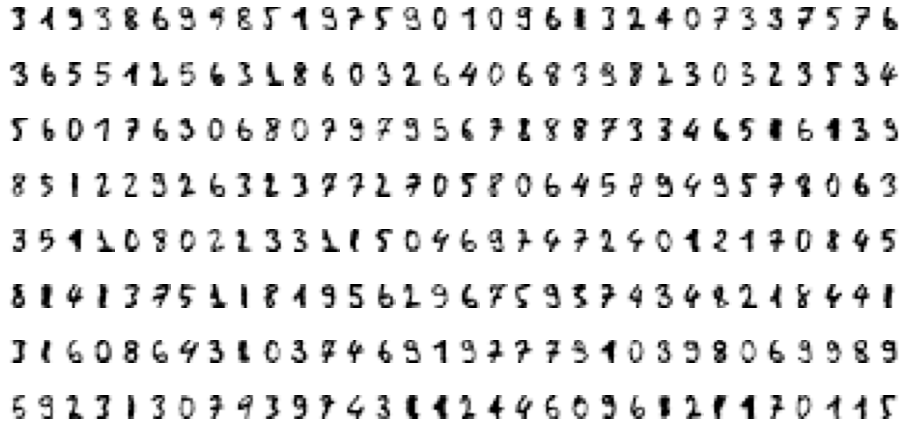

In [4]:
plt.figure(figsize=(16, 8))

for ix in range(8  * 32):
    plt.subplot(8, 32, ix + 1)
    plt.imshow(x_train[ix].reshape(8, 8), cmap='Greys')
    plt.axis('off')

### Visualizando o conjunto e frequências das classes

C:\Users\danil\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\danil\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


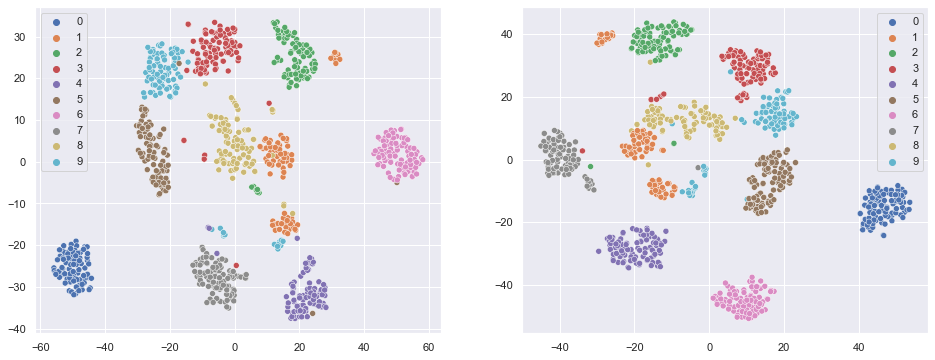

In [5]:
from sklearn.manifold import TSNE

encoder2D = TSNE()
w_train = encoder2D.fit_transform(x_train)
w_test = encoder2D.fit_transform(x_test)

plt.figure(figsize=(16, 6))
categorical_colors = sns.color_palette()

for ix, (x, y) in enumerate(((w_train, y_train), (w_test, y_test))):
    plt.subplot(1, 2, ix + 1)
    sns.scatterplot(*x.T,hue=y, palette=categorical_colors)

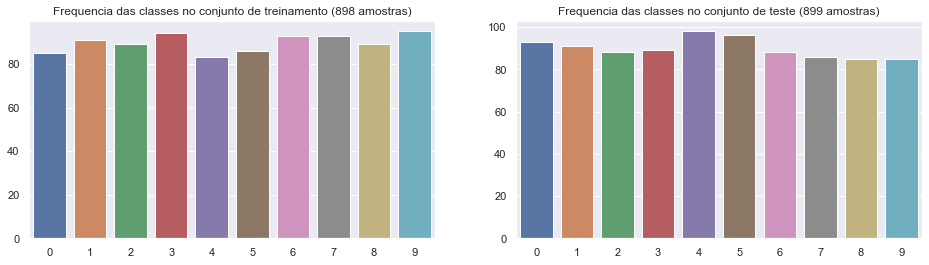

In [6]:
plt.figure(figsize=(16, 4))

plt.subplot(121)
plt.title('Frequencia das classes no conjunto de treinamento (%i amostras)' % len(x_train))
labels, counts = np.unique(y_train, return_counts=True)
sns.barplot(x=labels, y=counts)

plt.subplot(122)
plt.title('Frequencia das classes no conjunto de teste (%i amostras)' % len(x_test))
labels, counts = np.unique(y_test, return_counts=True)
sns.barplot(x=labels, y=counts);

### Modelando um classificador de digitos

**Atividade (3 pts):** defina e treine uma máquina de vetor de suporte com diferentes tipos de kernel, utilizando o scikit-learn. Avalie os diversos tipos de kernel e seus respectivos parâmetros com relação a qualidade da solução. Você deve separar uma parte do conjunto de treino para fazer a validação cruzada. Não utilize o conjunto de teste ainda.

Dividindo em Treino (80%) e Validação (20%)

In [7]:
new_x_train, x_val, new_y_train, y_val = train_test_split(x_train, y_train,
                                                    test_size=.2,
                                                    random_state=183212)

print('amostras em treino: %i' % new_x_train.shape[0],
      'amostras em teste: %i' % x_val.shape[0],
      'número de características: %i' % new_x_train.shape[1],
      'número de classes: %i' % (np.max(new_y_train) + 1),
      sep='\n', end='\n\n')

amostras em treino: 718
amostras em teste: 180
número de características: 64
número de classes: 10



Treinando SVM:

In [8]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from itertools import product

Treinando SVM RBF

In [9]:
clf = SVC(kernel='rbf')
clf.fit(new_x_train, new_y_train) 

pred = clf.predict(new_x_train)
#print(classification_report(new_y_train, pred))
#print(confusion_matrix(new_y_train, pred))

# calculamos a acc de treino e validação
trainAcc = accuracy_score(new_y_train, clf.predict(new_x_train))
valAcc = accuracy_score(y_val, clf.predict(x_val))

print("Acuracia Treino: %.3f\nAcuracia Validação: %.3f" % (trainAcc, valAcc))

Acuracia Treino: 0.993
Acuracia Validação: 0.994


Treinando SVM Linear

In [10]:
clf = SVC(kernel='linear')
clf.fit(new_x_train, new_y_train) 

pred = clf.predict(new_x_train)
#print(classification_report(new_y_train, pred))
#print(confusion_matrix(new_y_train, pred))

# calculamos a acc de treino e validação
trainAcc = accuracy_score(new_y_train, clf.predict(new_x_train))
valAcc = accuracy_score(y_val, clf.predict(x_val))

print("Acuracia Treino: %.3f\nAcuracia Validação: %.3f" % (trainAcc, valAcc))

Acuracia Treino: 1.000
Acuracia Validação: 0.978


Treinando SVM Poly

In [11]:
clf = SVC(kernel='poly')
clf.fit(new_x_train, new_y_train) 

pred = clf.predict(new_x_train)
#print(classification_report(new_y_train, pred))
#print(confusion_matrix(new_y_train, pred))

# calculamos a acc de treino e validação
trainAcc = accuracy_score(new_y_train, clf.predict(new_x_train))
valAcc = accuracy_score(y_val, clf.predict(x_val))

print("Acuracia Treino: %.3f\nAcuracia Validação: %.3f" % (trainAcc, valAcc))

Acuracia Treino: 0.999
Acuracia Validação: 0.989


Variando os parâmetros 

In [12]:
penaltyArray = [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]
gammaArray   = [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]
degreeArray  = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [13]:
from sklearn.model_selection import GridSearchCV

#RBF
param_grid = {'C':penaltyArray, 
              'gamma':gammaArray, 
              'kernel':['rbf']}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, scoring='accuracy')
grid.fit(new_x_train, new_y_train)
print('Melhor Score: %.3f\nMelhores parametros para RBF: %s\n' % (grid.best_score_, grid.best_params_))

#Linear
param_grid = {'C':penaltyArray, 
              'gamma':gammaArray, 
              'kernel':['linear']}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, scoring='accuracy')
grid.fit(new_x_train, new_y_train)
print('Melhor Score: %.3f\nMelhores parametros para Linear: %s\n' % (grid.best_score_, grid.best_params_))

#Poly
param_grid = {'C':penaltyArray, 
              'degree':degreeArray,
              'kernel':['poly']}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, scoring='accuracy')
grid.fit(new_x_train, new_y_train)

print('Melhor Score: %.3f\nMelhores parametros para Poly: %s\n' % (grid.best_score_, grid.best_params_))

Fitting 5 folds for each of 49 candidates, totalling 245 fits
Melhor Score: 0.985
Melhores parametros para RBF: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}

Fitting 5 folds for each of 49 candidates, totalling 245 fits
Melhor Score: 0.968
Melhores parametros para Linear: {'C': 0.01, 'gamma': 0.001, 'kernel': 'linear'}

Fitting 5 folds for each of 70 candidates, totalling 350 fits
Melhor Score: 0.979
Melhores parametros para Poly: {'C': 1, 'degree': 4, 'kernel': 'poly'}



### Avaliando o modelo treinado

**Atividade (2 pts):** avalie o seu melhor modelo treinado no item anterior sobre o conjunto de teste previamente separado. Reporte a acurácia média, a matriz de confusão e outras métricas que achar válido.

Acurácia

In [14]:
best_clf = SVC(kernel='rbf', C=10, gamma=0.001)
best_clf.fit(new_x_train, new_y_train) 

testPred = best_clf.predict(x_test)


# Acurácia Média
trainAcc = accuracy_score(new_y_train, best_clf.predict(new_x_train))
valAcc   = accuracy_score(y_val, best_clf.predict(x_val))
testAcc  = accuracy_score(y_test, testPred)

print("Acuracia Treino:    %.3f" % (trainAcc),
      "Acuracia Validação: %.3f" % (valAcc),
      "Acuracia Teste:     %.3f" % (testAcc),
      sep='\n',end='\n\n')

Acuracia Treino:    1.000
Acuracia Validação: 0.994
Acuracia Teste:     0.988



In [15]:
# Matriz de Confusão
print(confusion_matrix(y_test, testPred))

[[92  0  0  0  1  0  0  0  0  0]
 [ 0 91  0  0  0  0  0  0  0  0]
 [ 0  0 88  0  0  0  0  0  0  0]
 [ 0  0  1 88  0  0  0  0  0  0]
 [ 0  0  0  0 98  0  0  0  0  0]
 [ 0  0  0  0  0 95  0  0  0  1]
 [ 0  0  0  0  0  1 86  0  1  0]
 [ 0  0  0  0  0  0  0 84  0  2]
 [ 0  2  0  0  0  0  0  0 83  0]
 [ 0  0  0  1  0  0  0  0  1 83]]


In [16]:
print(classification_report(y_test, testPred, digits=3))

              precision    recall  f1-score   support

           0      1.000     0.989     0.995        93
           1      0.978     1.000     0.989        91
           2      0.989     1.000     0.994        88
           3      0.989     0.989     0.989        89
           4      0.990     1.000     0.995        98
           5      0.990     0.990     0.990        96
           6      1.000     0.977     0.989        88
           7      1.000     0.977     0.988        86
           8      0.976     0.976     0.976        85
           9      0.965     0.976     0.971        85

    accuracy                          0.988       899
   macro avg      0.988     0.987     0.988       899
weighted avg      0.988     0.988     0.988       899



**Atividade (4 pts):** treine dois ou mais classificadores (Random forest, logistic regression, etc.) e reporte o suas respectivas métricas sobre as porções de validação separadas (acurácia, acurácia balanceada, precision, etc). Compare seus melhores classificadores com os resultados da SVM no conjunto de teste. 



**Random Forest**

In [17]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(8)

rfModel = RandomForestClassifier()
rfModel.fit(new_x_train, new_y_train)

trainPred = rfModel.predict(new_x_train)
valPred   = rfModel.predict(x_val)

# Acurácia de treino e validação
trainAcc = accuracy_score(new_y_train, trainPred)
valAcc   = accuracy_score(y_val, valPred)

print("Acurácia Treino:    %.3f" % (trainAcc),
      "Acurácia Validação: %.4f" % (valAcc),
      sep='\n',end='\n\n')

Acurácia Treino:    1.000
Acurácia Validação: 0.9833



In [18]:
# Acurácia Balanceada
print('Acurácia Balanceada Treino:    %.3f' % (balanced_accuracy_score(new_y_train, trainPred)))
print('Acurácia Balanceada Validação: %.4f' % (balanced_accuracy_score(y_val, valPred)))

Acurácia Balanceada Treino:    1.000
Acurácia Balanceada Validação: 0.9825


In [19]:
# Precisão e outras métricas

display(Markdown("**Treino**"))
print(classification_report(new_y_train, trainPred, digits=3))

display(Markdown("**Validação**"))
print(classification_report(y_val, valPred, digits=3))

**Treino**

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        67
           1      1.000     1.000     1.000        75
           2      1.000     1.000     1.000        72
           3      1.000     1.000     1.000        75
           4      1.000     1.000     1.000        65
           5      1.000     1.000     1.000        71
           6      1.000     1.000     1.000        74
           7      1.000     1.000     1.000        66
           8      1.000     1.000     1.000        72
           9      1.000     1.000     1.000        81

    accuracy                          1.000       718
   macro avg      1.000     1.000     1.000       718
weighted avg      1.000     1.000     1.000       718



**Validação**

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        18
           1      1.000     1.000     1.000        16
           2      1.000     1.000     1.000        17
           3      1.000     0.947     0.973        19
           4      1.000     0.944     0.971        18
           5      1.000     0.933     0.966        15
           6      0.950     1.000     0.974        19
           7      0.964     1.000     0.982        27
           8      0.944     1.000     0.971        17
           9      1.000     1.000     1.000        14

    accuracy                          0.983       180
   macro avg      0.986     0.983     0.984       180
weighted avg      0.984     0.983     0.983       180



**Logistic Regression**

In [20]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

np.random.seed(8)

lr = LogisticRegression(random_state=0, max_iter=5000)
lr.fit(new_x_train, new_y_train)

trainPred = lr.predict(new_x_train)
valPred   = lr.predict(x_val)

# Acurácia de treino e validação
trainAcc = accuracy_score(new_y_train, trainPred)
valAcc   = accuracy_score(y_val, valPred)

print("Acurácia Treino:    %.3f" % (trainAcc),
      "Acurácia Validação: %.3f" % (valAcc),
      sep='\n',end='\n\n')

Acurácia Treino:    1.000
Acurácia Validação: 0.956



In [21]:
# Acurácia Balanceada
print('Acurácia Balanceada Treino:    %.3f' % (balanced_accuracy_score(new_y_train, trainPred)))
print('Acurácia Balanceada Validação: %.3f' % (balanced_accuracy_score(y_val, valPred)))

Acurácia Balanceada Treino:    1.000
Acurácia Balanceada Validação: 0.952


In [22]:
display(Markdown("**Treino**"))
print(classification_report(new_y_train, trainPred, digits=3))

display(Markdown("**Validação**"))
print(classification_report(y_val, valPred, digits=3))

**Treino**

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        67
           1      1.000     1.000     1.000        75
           2      1.000     1.000     1.000        72
           3      1.000     1.000     1.000        75
           4      1.000     1.000     1.000        65
           5      1.000     1.000     1.000        71
           6      1.000     1.000     1.000        74
           7      1.000     1.000     1.000        66
           8      1.000     1.000     1.000        72
           9      1.000     1.000     1.000        81

    accuracy                          1.000       718
   macro avg      1.000     1.000     1.000       718
weighted avg      1.000     1.000     1.000       718



**Validação**

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        18
           1      0.933     0.875     0.903        16
           2      1.000     1.000     1.000        17
           3      1.000     0.895     0.944        19
           4      0.944     0.944     0.944        18
           5      0.867     0.867     0.867        15
           6      0.950     1.000     0.974        19
           7      0.964     1.000     0.982        27
           8      0.941     0.941     0.941        17
           9      0.933     1.000     0.966        14

    accuracy                          0.956       180
   macro avg      0.953     0.952     0.952       180
weighted avg      0.956     0.956     0.955       180



**Conjunto de Teste**

In [23]:
svmTestPred = best_clf.predict(x_test)
rfTestPred  = rfModel.predict(x_test)

# Acurácia
print("Acurácia Teste Melhor SVM:    %.3f" % (accuracy_score(y_test, svmTestPred)),
      "Acurácia Teste Random Forest: %.3f" % (accuracy_score(y_test, rfTestPred)),
      sep='\n',end='\n\n')

Acurácia Teste Melhor SVM:    0.988
Acurácia Teste Random Forest: 0.962



In [24]:
# Acurácia Balanceada
print('Acurácia Balanceada Melhor SVM:    %.3f' % (balanced_accuracy_score(y_test, svmTestPred)))
print('Acurácia Balanceada Random Forest: %.3f' % (balanced_accuracy_score(y_test, rfTestPred)))

Acurácia Balanceada Melhor SVM:    0.987
Acurácia Balanceada Random Forest: 0.961


In [25]:
# Matriz de Confusão
display(Markdown("**SVM**"))
print(confusion_matrix(y_test, svmTestPred))

display(Markdown("**Random Forest**"))
print(confusion_matrix(y_test, rfTestPred))

**SVM**

[[92  0  0  0  1  0  0  0  0  0]
 [ 0 91  0  0  0  0  0  0  0  0]
 [ 0  0 88  0  0  0  0  0  0  0]
 [ 0  0  1 88  0  0  0  0  0  0]
 [ 0  0  0  0 98  0  0  0  0  0]
 [ 0  0  0  0  0 95  0  0  0  1]
 [ 0  0  0  0  0  1 86  0  1  0]
 [ 0  0  0  0  0  0  0 84  0  2]
 [ 0  2  0  0  0  0  0  0 83  0]
 [ 0  0  0  1  0  0  0  0  1 83]]


**Random Forest**

[[91  0  0  0  2  0  0  0  0  0]
 [ 0 89  0  0  0  0  1  0  1  0]
 [ 0  0 88  0  0  0  0  0  0  0]
 [ 0  0  0 85  0  0  0  1  2  1]
 [ 0  0  0  0 97  0  1  0  0  0]
 [ 0  0  0  0  1 94  1  0  0  0]
 [ 1  1  0  0  1  0 84  0  1  0]
 [ 0  0  0  0  2  0  0 76  0  8]
 [ 0  2  1  0  0  0  0  0 81  1]
 [ 0  0  0  2  0  1  0  0  2 80]]


In [26]:
display(Markdown("**SVM**"))
print(classification_report(y_test, svmTestPred, digits=3))

display(Markdown("**Random Forest**"))
print(classification_report(y_test, rfTestPred, digits=3))

**SVM**

              precision    recall  f1-score   support

           0      1.000     0.989     0.995        93
           1      0.978     1.000     0.989        91
           2      0.989     1.000     0.994        88
           3      0.989     0.989     0.989        89
           4      0.990     1.000     0.995        98
           5      0.990     0.990     0.990        96
           6      1.000     0.977     0.989        88
           7      1.000     0.977     0.988        86
           8      0.976     0.976     0.976        85
           9      0.965     0.976     0.971        85

    accuracy                          0.988       899
   macro avg      0.988     0.987     0.988       899
weighted avg      0.988     0.988     0.988       899



**Random Forest**

              precision    recall  f1-score   support

           0      0.989     0.978     0.984        93
           1      0.967     0.978     0.973        91
           2      0.989     1.000     0.994        88
           3      0.977     0.955     0.966        89
           4      0.942     0.990     0.965        98
           5      0.989     0.979     0.984        96
           6      0.966     0.955     0.960        88
           7      0.987     0.884     0.933        86
           8      0.931     0.953     0.942        85
           9      0.889     0.941     0.914        85

    accuracy                          0.962       899
   macro avg      0.963     0.961     0.961       899
weighted avg      0.963     0.962     0.962       899



**Pergunta (1pt):** qual classificador apresentou os melhores resultados? Qual critério você utilizou para definir sua escolha? Discuta.

Os dois classificadores, SVM e Random Forest, performaram muito bem com valores de acurácia, acurácia balanceada e f1 score acima de 95 e com pouca diferença e. Porém o classificador que apresentou os melhores resultados foi SVM com kernel rbf, que obteve valores melhores que a Random Forest em todas as métricas observadas. Inclusive apresentou f1 score melhor para cada classe individual.